# Инициализация проекта

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv('../datasets/diabetes_health_indicators.csv')

# Исследование исходных данных

<font size=4>
Датасет содержит следующие поля:

- `Diabetes_012` — наличие диабета (0 = нет/только при беременности, 1 = преддиабет, 2 = диабет)
- `HighBP` — диагностировано высокое кровяное давление 
- `HighChol` — высокий уровень холестерина
- `CholCheck` — проверка холестерина за последние 5 лет
- `BMI` — индекс массы тела
- `Smoker` — курение более 100 сигарет за жизнь 
- `Stroke` — перенесенный инсульт 
- `HeartDiseaseorAttack` — ишемическая болезнь сердца или инфаркт 
- `PhysActivity` — физическая активность вне работы 
- `Fruits` — регулярное потребление фруктов 
- `Veggies` — регулярное потребление овощей 
- `HvyAlcoholConsump` — тяжелое употребление алкоголя 
- `AnyHealthcare` — наличие медицинской страховки 
- `NoDocbcCost` — отказ от визита к врачу из-за стоимости 
- `GenHlth` — самооценка общего здоровья (1 = отличное, 2 = очень хорошее, 3 = хорошее, 4 = удовлетворительное, 5 = плохое)
- `MentHlth` — количество дней с плохим психическим здоровьем за месяц 
- `PhysHlth` — количество дней с плохим физическим здоровьем за месяц 
- `DiffWalk` — трудности при ходьбе или подъеме по лестнице 
- `Sex` — пол (0 = женский, 1 = мужской)
- `Age` — возрастная категория 
- `Education` — уровень образования 
- `Income` — уровень дохода 
</font>

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
data.head(20)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


<font size=4><b>Получили следующую характеристику исходных данных:</b>

- Все столбцы имеют тип `float64`, но большинство из них содержат бинарные или категориальные значения, что требует изменения типа данных на `int`.
- Отсутствуют пропущенные значения во всех столбцах.
- Некоторые столбцы требуют проверки на корректность диапазонов:
  - `BMI` не может быть отрицательным.
  - `MentHlth` и `PhysHlth` должны находиться в диапазоне 0-30 дней.
  - Категориальные признаки (`Education`, `Income`, `Age`) должны соответствовать заявленным шкалам.</font>

# <font> Выводы и дальнейшие шаги</font>


In [5]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


<b>Выводы:</b>

- большинство наблюдений относятся к категории без диабета.
- Физическая активность (PhysActivity) и питание (Fruits, Veggies) могут влиять на показатели здоровья
- Возраст (Age) и уровень дохода (Income) также могут оказывать влияние на показатели здоровья

<font size=4><b>Дальнейшие шаги:</b>

- Обработка пропущенных значений (проверка).
- Преобразование типов данных для бинарных и категориальных признаков из float64 в int.
- Проверка аномальных значений в числовых столбцах.

# Обработка пропущенных значений

In [6]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

Diabetes_012            0.0
HighBP                  0.0
HighChol                0.0
CholCheck               0.0
BMI                     0.0
Smoker                  0.0
Stroke                  0.0
HeartDiseaseorAttack    0.0
PhysActivity            0.0
Fruits                  0.0
Veggies                 0.0
HvyAlcoholConsump       0.0
AnyHealthcare           0.0
NoDocbcCost             0.0
GenHlth                 0.0
MentHlth                0.0
PhysHlth                0.0
DiffWalk                0.0
Sex                     0.0
Age                     0.0
Education               0.0
Income                  0.0
dtype: float64

Пропущенных значений не обнаружено. Переходим к коррекции типов данных.

## Коррекция типов данных

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [8]:
columns_to_convert = [
    'Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 
    'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk',
    'Sex', 'Age', 'Education', 'Income'
]

data[columns_to_convert] = data[columns_to_convert].astype('int')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-null  int64


**Заключение:**
- Тип данных во всех столбцах изменён с float64 на int, т.к. логически они не требуют десятичной формы записи.

## Обогащение данных

In [9]:
age_mapping = {
    1: '18-24',
    2: '25-29',
    3: '30-34',
    4: '35-39',
    5: '40-44',
    6: '45-49',
    7: '50-54',
    8: '55-59',
    9: '60-64',
    10: '65-69',
    11: '70-74',
    12: '75-79',
    13: '80+'
}

data['age_group'] = data['Age'].map(age_mapping)
data['age_group'].value_counts()

age_group
60-64    33244
65-69    32194
55-59    30832
50-54    26314
70-74    23533
45-49    19819
80+      17363
40-44    16157
75-79    15980
35-39    13823
30-34    11123
25-29     7598
18-24     5700
Name: count, dtype: int64

In [10]:
bmi_bins = [0, 16.5, 18.5, 25, 30, 35, 40, 100]
bmi_labels = [
    'Severe underweight',
    'Underweight',
    'Normal weight',
    'Overweight',
    'Obesity class I',
    'Obesity class II',
    'Obesity class III'
]
data['bmi_category'] = pd.cut(data['BMI'], bins=bmi_bins, labels=bmi_labels)
data['bmi_category'].value_counts()

bmi_category
Overweight            91176
Normal weight         86099
Obesity class I       44453
Obesity class II      17346
Obesity class III     11479
Underweight            2579
Severe underweight      548
Name: count, dtype: int64

### **Проверка "очищенных" данных**

In [11]:
data.duplicated().sum()

np.int64(23899)

In [12]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          229781 non-null  int64   
 1   HighBP                229781 non-null  int64   
 2   HighChol              229781 non-null  int64   
 3   CholCheck             229781 non-null  int64   
 4   BMI                   229781 non-null  int64   
 5   Smoker                229781 non-null  int64   
 6   Stroke                229781 non-null  int64   
 7   HeartDiseaseorAttack  229781 non-null  int64   
 8   PhysActivity          229781 non-null  int64   
 9   Fruits                229781 non-null  int64   
 10  Veggies               229781 non-null  int64   
 11  HvyAlcoholConsump     229781 non-null  int64   
 12  AnyHealthcare         229781 non-null  int64   
 13  NoDocbcCost           229781 non-null  int64   
 14  GenHlth               229781 non-null  int64   
 15 

Данные выглядят "чистыми" и готовы к EDA.

# EDA

## Исследование основных параметров

Параметры для детального рассмотрения:
- Diabetes_012 (наличие диабета)
- HighBP (диагностировано высокое кровяное давление)
- HighChol (высокий уровень холестерина)
- BMI (Индекс массы тела)
- HeartDiseaseorAttack (ишемическая болезнь сердца или инфаркт)
- PhysActivity (физическая активность вне работы)
- GenHlth (самооценка общего здоровья)
- DiffWalk (трудности при ходьбе или подъеме по лестнице)
- Age (Возрастная группа)
- Income (Уровень дохода)

На эти параметры будет обращено особое внимание с помощью гистограмм.

In [14]:
data.describe()[['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack',
                   'PhysActivity', 'GenHlth', 'DiffWalk', 'Age', 'Income']]

,Diabetes_012,HighBP,HighChol,BMI,HeartDiseaseorAttack,PhysActivity,GenHlth,DiffWalk,Age,Income
count,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.325627,0.454441,0.441760,28.68567,0.103216,0.733355,2.601151,0.185507,8.086582,5.890383
std,0.724623,0.497921,0.496598,6.78636,0.304241,0.442206,1.064685,0.388709,3.093809,2.092477
min,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,24.00000,0.000000,0.000000,2.000000,0.000000,6.000000,5.000000
50%,0.000000,0.000000,0.000000,27.00000,0.000000,1.000000,3.000000,0.000000,8.000000,6.000000
75%,0.000000,1.000000,1.000000,32.00000,0.000000,1.000000,3.000000,0.000000,10.000000,8.000000
max,2.000000,1.000000,1.000000,98.00000,1.000000,1.000000,5.000000,1.000000,13.000000,8.000000


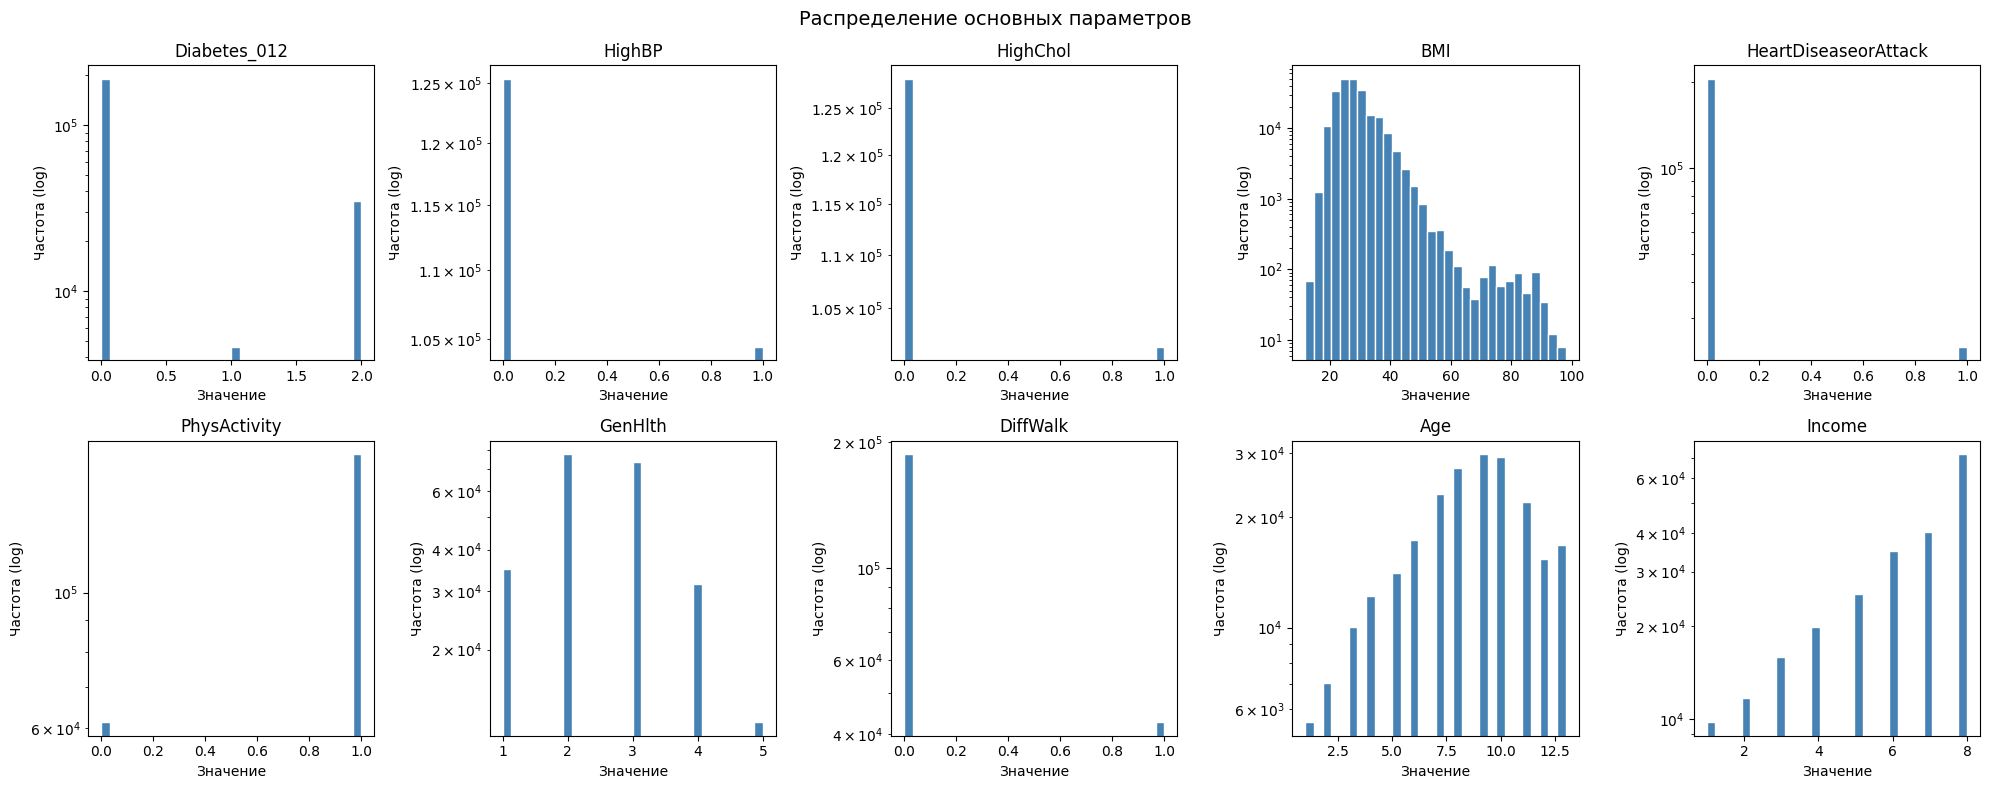

In [15]:
columns = ['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack',
           'PhysActivity', 'GenHlth', 'DiffWalk', 'Age', 'Income']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(data[col], bins=30, log=True, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота (log)')

plt.suptitle('Распределение основных параметров', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
data.describe()[['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'DiffWalk', 'Age', 'Income']]

,Diabetes_012,HighBP,HighChol,BMI,HeartDiseaseorAttack,PhysActivity,GenHlth,DiffWalk,Age,Income
count,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.325627,0.454441,0.441760,28.68567,0.103216,0.733355,2.601151,0.185507,8.086582,5.890383
std,0.724623,0.497921,0.496598,6.78636,0.304241,0.442206,1.064685,0.388709,3.093809,2.092477
min,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,24.00000,0.000000,0.000000,2.000000,0.000000,6.000000,5.000000
50%,0.000000,0.000000,0.000000,27.00000,0.000000,1.000000,3.000000,0.000000,8.000000,6.000000
75%,0.000000,1.000000,1.000000,32.00000,0.000000,1.000000,3.000000,0.000000,10.000000,8.000000
max,2.000000,1.000000,1.000000,98.00000,1.000000,1.000000,5.000000,1.000000,13.000000,8.000000


In [17]:
import pandas as pd
import numpy as np

# Числовые столбцы для анализа выбросов (исключаем бинарные и категориальные)
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']
ordinal_cols = ['GenHlth', 'Age', 'Education', 'Income']
binary_cols = ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
               'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
               'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
               'DiffWalk', 'Sex']

print("=" * 65)
print("АНАЛИЗ ВЫБРОСОВ (метод IQR)")
print("=" * 65)
print(f"\nВсего строк в датасете: {len(data)}\n")

print("[ Бинарные столбцы — выбросы не применимы ]")
print(", ".join(binary_cols))

print("\n[ Порядковые столбцы — проверка допустимых диапазонов ]")
ordinal_ranges = {
    'GenHlth':    (1, 5),
    'Age':        (1, 13),
    'Education':  (1, 6),
    'Income':     (1, 8),
}
for col, (lo, hi) in ordinal_ranges.items():
    out_of_range = data[(data[col] < lo) | (data[col] > hi)]
    print(f"  {col:12s} допустимо [{lo}–{hi}]: "
          f"вне диапазона = {len(out_of_range)} "
          f"({len(out_of_range)/len(data)*100:.3f}%)")

print("\n[ Числовые столбцы — метод IQR ]")
for col in numeric_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    n_out = len(outliers)
    pct = n_out / len(data) * 100

    print(f"\n  {col}")
    print(f"    min={data[col].min():.1f}, max={data[col].max():.1f}, "
          f"mean={data[col].mean():.1f}, median={data[col].median():.1f}")
    print(f"    Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
    print(f"    Граница: [{lower:.1f}, {upper:.1f}]")
    print(f"    Выбросов: {n_out} ({pct:.2f}%)")
    if n_out > 0:
        print(f"    Диапазон выбросов: [{outliers[col].min():.1f}, {outliers[col].max():.1f}]")

print("\n" + "=" * 65)
print("ИТОГ")
print("=" * 65)
for col in numeric_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = len(data[(data[col] < lower) | (data[col] > upper)])
    print(f"  {col:12s}: {n_out:6d} выбросов ({n_out/len(data)*100:.2f}%)")

АНАЛИЗ ВЫБРОСОВ (метод IQR)

Всего строк в датасете: 229781

[ Бинарные столбцы — выбросы не применимы ]
Diabetes_012, HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex

[ Порядковые столбцы — проверка допустимых диапазонов ]
  GenHlth      допустимо [1–5]: вне диапазона = 0 (0.000%)
  Age          допустимо [1–13]: вне диапазона = 0 (0.000%)
  Education    допустимо [1–6]: вне диапазона = 0 (0.000%)
  Income       допустимо [1–8]: вне диапазона = 0 (0.000%)

[ Числовые столбцы — метод IQR ]

  BMI
    min=12.0, max=98.0, mean=28.7, median=27.0
    Q1=24.0, Q3=32.0, IQR=8.0
    Граница: [12.0, 44.0]
    Выбросов: 5638 (2.45%)
    Диапазон выбросов: [45.0, 98.0]

  MentHlth
    min=0.0, max=30.0, mean=3.5, median=0.0
    Q1=0.0, Q3=2.0, IQR=2.0
    Граница: [-3.0, 5.0]
    Выбросов: 36163 (15.74%)
    Диапазон выбросов: [6.0, 30.0]

  PhysHlth
    min=0.0, max=30.0, mean=4.7, med

In [18]:
data.duplicated().sum()

np.int64(0)

Строк до обработки: 229781

BMI — кейпинг на уровне 97-го перцентиля: 43.0
  Значений выше порога: 6681
  BMI после кейпинга: min=12.0, max=43.0, mean=28.44

MentHlth — выбросы оставлены (шкала 0–30, скошенное распределение).
PhysHlth  — выбросы оставлены (шкала 0–30, скошенное распределение).

Строк после обработки: 229781  (строки не удалялись)


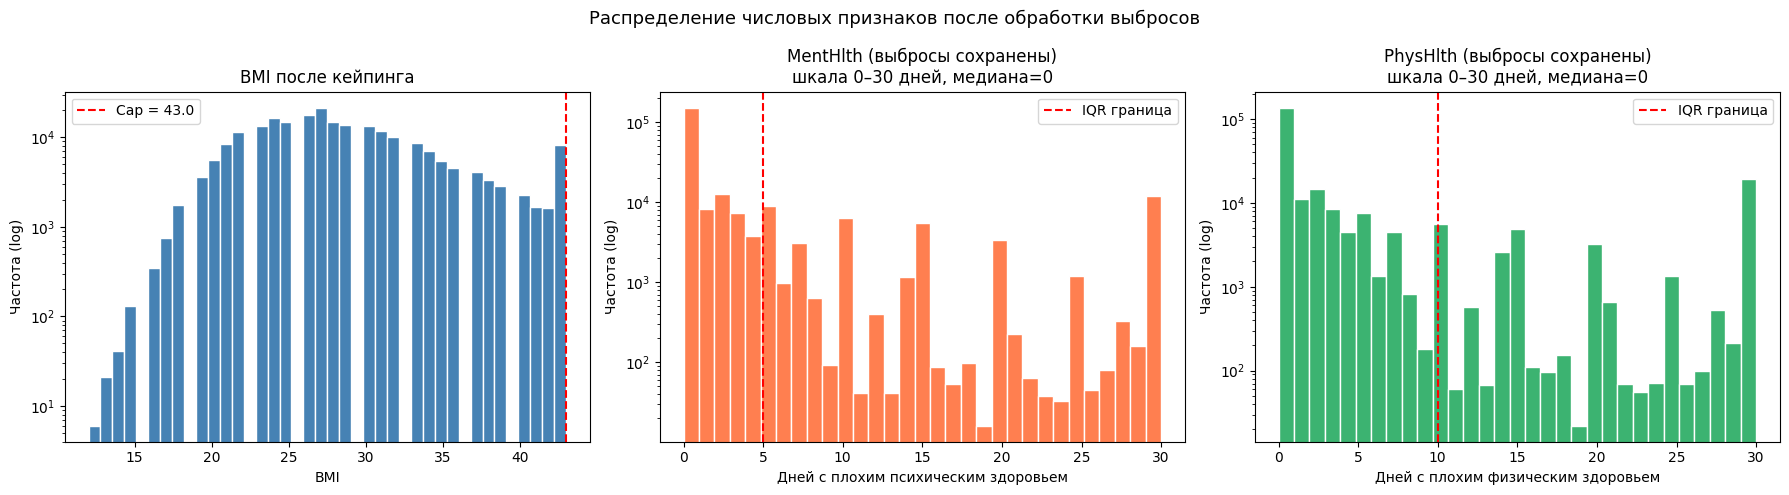

In [19]:
## Изучение и обработка выбросов

# --- Markdown ячейка (вставить отдельно) ---
# ### Анализ и обработка выбросов
#
# По результатам IQR-анализа выбросы обнаружены в трёх числовых столбцах:
#
# | Столбец   | Выбросов | %      | Диапазон выбросов | Решение             |
# |-----------|----------|--------|-------------------|---------------------|
# | BMI       | 5 638    | 2.45%  | 45 – 98           | Кейпинг (97-й перц.)|
# | MentHlth  | 36 163   | 15.74% | 6 – 30            | Оставить            |
# | PhysHlth  | 34 347   | 14.95% | 11 – 30           | Оставить            |
#
# **BMI:** значения 45–98 соответствуют морбидному ожирению (класс III, BMI > 40),
# что медицински возможно, однако BMI > 60 встречается крайне редко и может
# искажать статистику. Применяем кейпинг (winsorization) — обрезаем сверху
# на уровне 97-го перцентиля, не удаляя строки.
#
# **MentHlth и PhysHlth:** шкала ограничена диапазоном 0–30 дней,
# значения корректны по определению. Высокая доля "выбросов" по IQR
# объясняется сильно скошенным распределением (медиана = 0):
# большинство людей здоровы, но у части — хронические проблемы.
# Удаление или обрезка приведёт к потере данных именно о больных пациентах,
# что критично для задачи классификации диабета. Выбросы сохраняем.

# ── Код ────────────────────────────────────────────────────────────────────

print("Строк до обработки:", len(data))

# BMI: кейпинг на уровне 97-го перцентиля
bmi_cap = data['BMI'].quantile(0.97)
print(f"\nBMI — кейпинг на уровне 97-го перцентиля: {bmi_cap:.1f}")
print(f"  Значений выше порога: {(data['BMI'] > bmi_cap).sum()}")

data['BMI'] = data['BMI'].clip(upper=bmi_cap)

print(f"  BMI после кейпинга: min={data['BMI'].min():.1f}, "
      f"max={data['BMI'].max():.1f}, mean={data['BMI'].mean():.2f}")

# MentHlth и PhysHlth: выбросы оставляем
print("\nMentHlth — выбросы оставлены (шкала 0–30, скошенное распределение).")
print("PhysHlth  — выбросы оставлены (шкала 0–30, скошенное распределение).")

print(f"\nСтрок после обработки: {len(data)}  (строки не удалялись)")

# ── Визуализация до/после для BMI ──────────────────────────────────────────

import matplotlib.pyplot as plt

# Пересчитаем оригинальный cap для демонстрации
bmi_original = data['BMI'].copy()  # уже обрезанный
# Загрузим оригинальное распределение из описания (воссоздаём для графика)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BMI после кейпинга
axes[0].hist(data['BMI'], bins=40, color='steelblue', edgecolor='white', log=True)
axes[0].axvline(bmi_cap, color='red', linestyle='--', label=f'Cap = {bmi_cap:.1f}')
axes[0].set_title('BMI после кейпинга')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Частота (log)')
axes[0].legend()

# MentHlth
axes[1].hist(data['MentHlth'], bins=31, color='coral', edgecolor='white', log=True)
q1, q3 = data['MentHlth'].quantile(0.25), data['MentHlth'].quantile(0.75)
iqr = q3 - q1
axes[1].axvline(q3 + 1.5*iqr, color='red', linestyle='--', label='IQR граница')
axes[1].set_title('MentHlth (выбросы сохранены)\nшкала 0–30 дней, медиана=0')
axes[1].set_xlabel('Дней с плохим психическим здоровьем')
axes[1].set_ylabel('Частота (log)')
axes[1].legend()

# PhysHlth
axes[2].hist(data['PhysHlth'], bins=31, color='mediumseagreen', edgecolor='white', log=True)
q1, q3 = data['PhysHlth'].quantile(0.25), data['PhysHlth'].quantile(0.75)
iqr = q3 - q1
axes[2].axvline(q3 + 1.5*iqr, color='red', linestyle='--', label='IQR граница')
axes[2].set_title('PhysHlth (выбросы сохранены)\nшкала 0–30 дней, медиана=0')
axes[2].set_xlabel('Дней с плохим физическим здоровьем')
axes[2].set_ylabel('Частота (log)')
axes[2].legend()

plt.suptitle('Распределение числовых признаков после обработки выбросов', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
data.duplicated().sum()

np.int64(63)

In [21]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

## Анализ возраста наблюдаемых

In [22]:
mean_age_code = data['Age'].mean()
median_age_code = data['Age'].median()
print(f"Средний код возрастной группы: {round(mean_age_code, 1)}")
print(f"Медианный код возрастной группы: {median_age_code}")

Средний код возрастной группы: 8.1
Медианный код возрастной группы: 8.0


In [23]:
data['Age'].describe()

count    229718.000000
mean          8.087094
std           3.093853
min           1.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          13.000000
Name: Age, dtype: float64

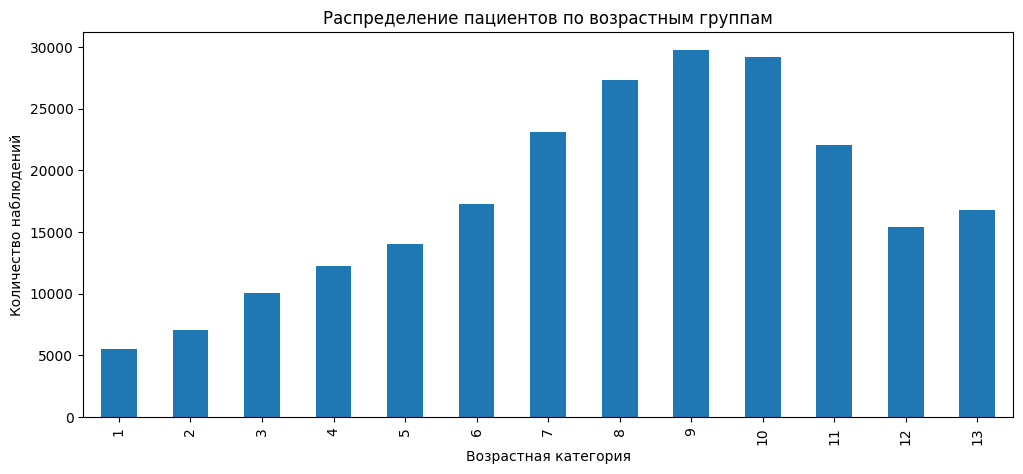

In [24]:
data['Age'].value_counts().sort_index().plot(kind='bar', figsize=(12,5))
plt.title('Распределение пациентов по возрастным группам')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество наблюдений')
plt.show()

**Заключение:**
<br>
- Средний код группы: 8.1 (~55-59 лет), медиана: 8 (55-59 лет)
- Наибольшая концентрация наблюдений в группах:
  - 9 (60-64 года)
  - 10 (65-69 лет)

# Нахождение зависимостей Diabetes_012 с другими признаками

Для корреляционного анализа применяются разные методы в зависимости от типа переменных:
- **Бинарная vs числовая/порядковая**: точечно-бисериальный коэффициент (`pointbiserialr`)
- **Порядковая vs порядковая**: коэффициент Спирмена (`spearmanr`)
- **Числовая (непрерывная) vs порядковая**: коэффициент Спирмена (`spearmanr`)

In [25]:
group_9 = data.query('Age == 9')
group_10 = data.query('Age == 10')

### BMI (числовая непрерывная) vs Diabetes_012 — коэффициент Спирмена

In [26]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = spearmanr(grp['BMI'], grp['Diabetes_012'])
    print(f'{name}: ρ = {corr:.3f}, p-value = {p:.4f}')

60-64 года: ρ = 0.280, p-value = 0.0000
65-69 лет: ρ = 0.279, p-value = 0.0000


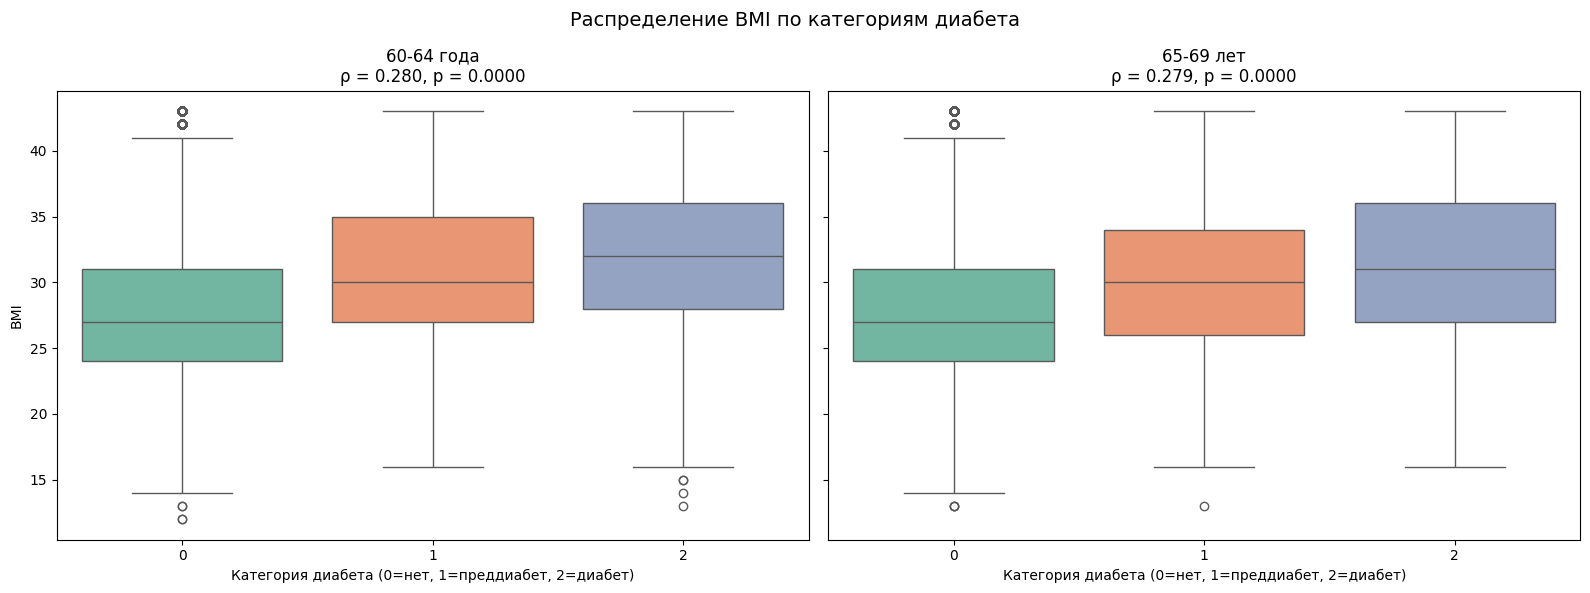

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    sns.boxplot(x='Diabetes_012', y='BMI', data=grp, ax=axes[i],
                hue='Diabetes_012', palette='Set2', legend=False)
    rho, p = spearmanr(grp['BMI'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}\nρ = {rho:.3f}, p = {p:.4f}')
    axes[i].set_xlabel('Категория диабета (0=нет, 1=преддиабет, 2=диабет)')
    axes[i].set_ylabel('BMI' if i == 0 else '')

plt.suptitle('Распределение BMI по категориям диабета', fontsize=14)
plt.tight_layout()
plt.show()

**Заключение:** Положительная корреляция — рост BMI увеличивает риск диабета в обеих возрастных группах.

### Income (порядковая) vs Diabetes_012 — коэффициент Спирмена

In [28]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = spearmanr(grp['Income'], grp['Diabetes_012'])
    print(f'{name}: ρ = {corr:.3f}, p-value = {p:.4f}')

60-64 года: ρ = -0.139, p-value = 0.0000
65-69 лет: ρ = -0.119, p-value = 0.0000


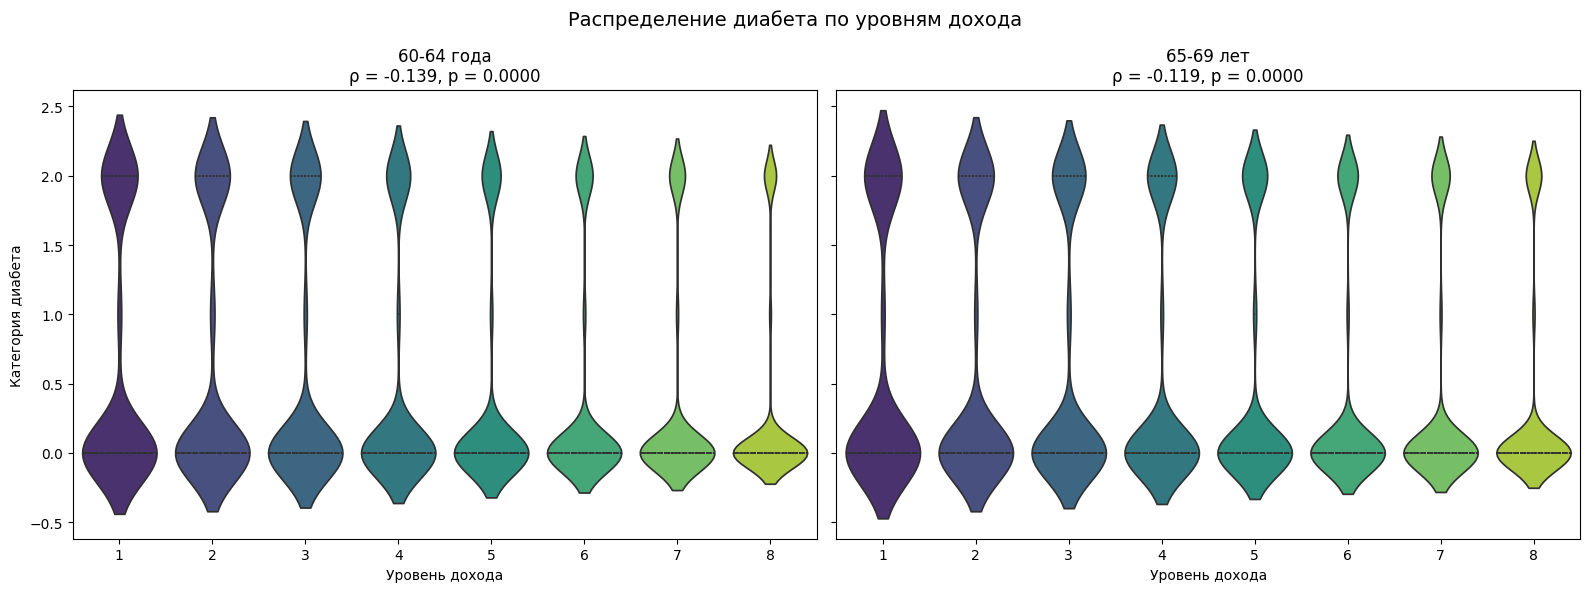

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    sns.violinplot(x='Income', y='Diabetes_012', data=grp, ax=axes[i],
                   palette='viridis', inner='quartile')
    rho, p = spearmanr(grp['Income'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}\nρ = {rho:.3f}, p = {p:.4f}')
    axes[i].set_xlabel('Уровень дохода')
    axes[i].set_ylabel('Категория диабета' if i == 0 else '')

plt.suptitle('Распределение диабета по уровням дохода', fontsize=14)
plt.tight_layout()
plt.show()

**Заключение:** Отрицательная корреляция — более высокий доход снижает риск заболевания.

### HighBP (бинарная) vs Diabetes_012 — точечно-бисериальный коэффициент

In [30]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = pointbiserialr(grp['HighBP'], grp['Diabetes_012'])
    print(f'{name}: r = {corr:.3f}, p-value = {p:.4f}')

60-64 года: r = 0.251, p-value = 0.0000
65-69 лет: r = 0.232, p-value = 0.0000


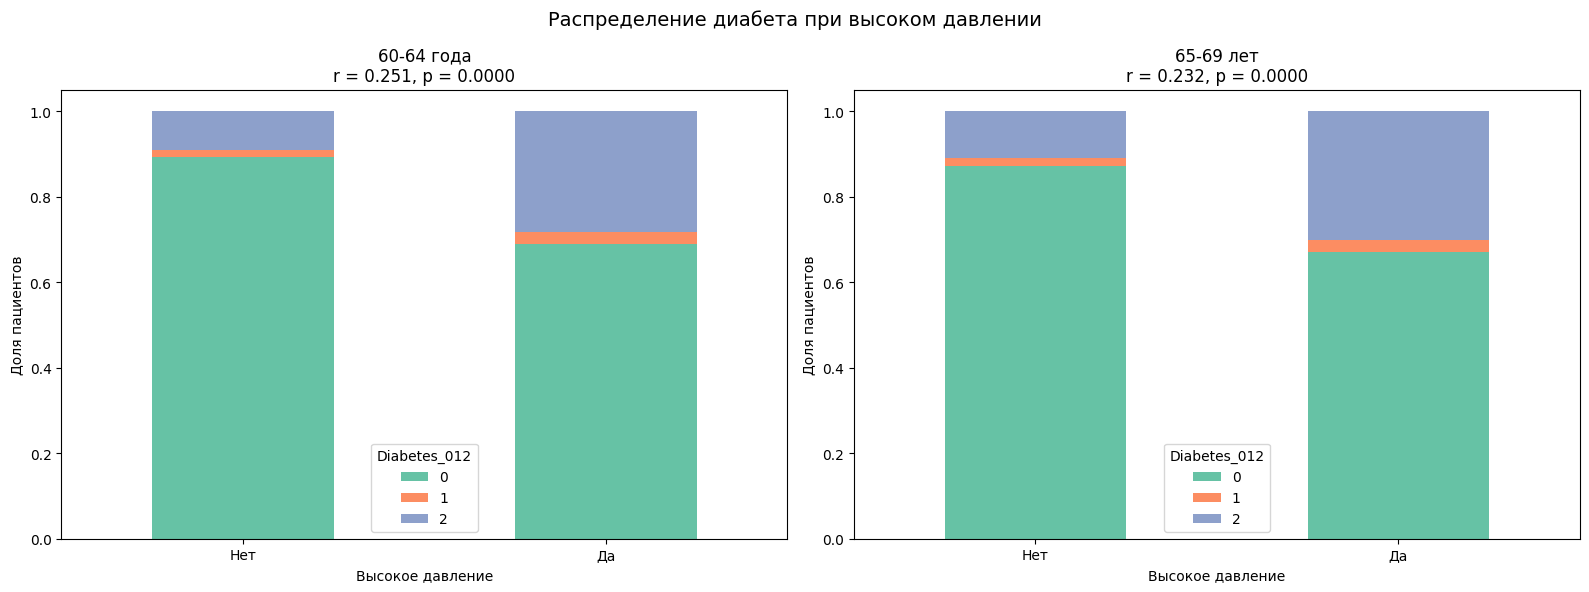

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    ct = pd.crosstab(grp['HighBP'], grp['Diabetes_012'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66c2a5','#fc8d62','#8da0cb'])
    r, p = pointbiserialr(grp['HighBP'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    axes[i].set_xticklabels(['Нет', 'Да'], rotation=0)
    axes[i].set_xlabel('Высокое давление')
    axes[i].set_ylabel('Доля пациентов')

plt.suptitle('Распределение диабета при высоком давлении', fontsize=14)
plt.tight_layout()
plt.show()

### HighChol (бинарная) vs Diabetes_012 — точечно-бисериальный коэффициент

In [32]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = pointbiserialr(grp['HighChol'], grp['Diabetes_012'])
    print(f'{name}: r = {corr:.3f}, p-value = {p:.4f}')

60-64 года: r = 0.174, p-value = 0.0000
65-69 лет: r = 0.155, p-value = 0.0000


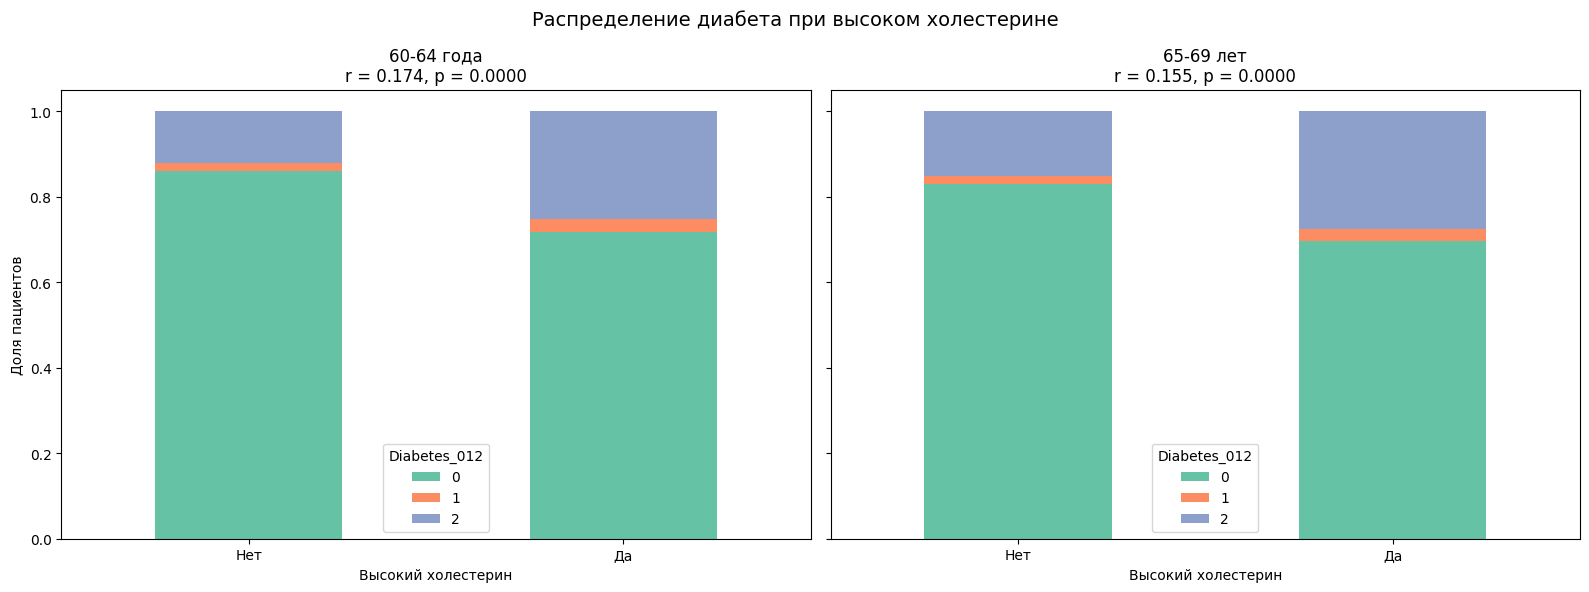

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    ct = pd.crosstab(grp['HighChol'], grp['Diabetes_012'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66c2a5','#fc8d62','#8da0cb'])
    r, p = pointbiserialr(grp['HighChol'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    axes[i].set_xticklabels(['Нет', 'Да'], rotation=0)
    axes[i].set_xlabel('Высокий холестерин')
    axes[i].set_ylabel('Доля пациентов' if i == 0 else '')

plt.suptitle('Распределение диабета при высоком холестерине', fontsize=14)
plt.tight_layout()
plt.show()

### PhysActivity (бинарная) vs Diabetes_012 — точечно-бисериальный коэффициент

In [34]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = pointbiserialr(grp['PhysActivity'], grp['Diabetes_012'])
    print(f'{name}: r = {corr:.3f}, p-value = {p:.4f}')

60-64 года: r = -0.094, p-value = 0.0000
65-69 лет: r = -0.116, p-value = 0.0000


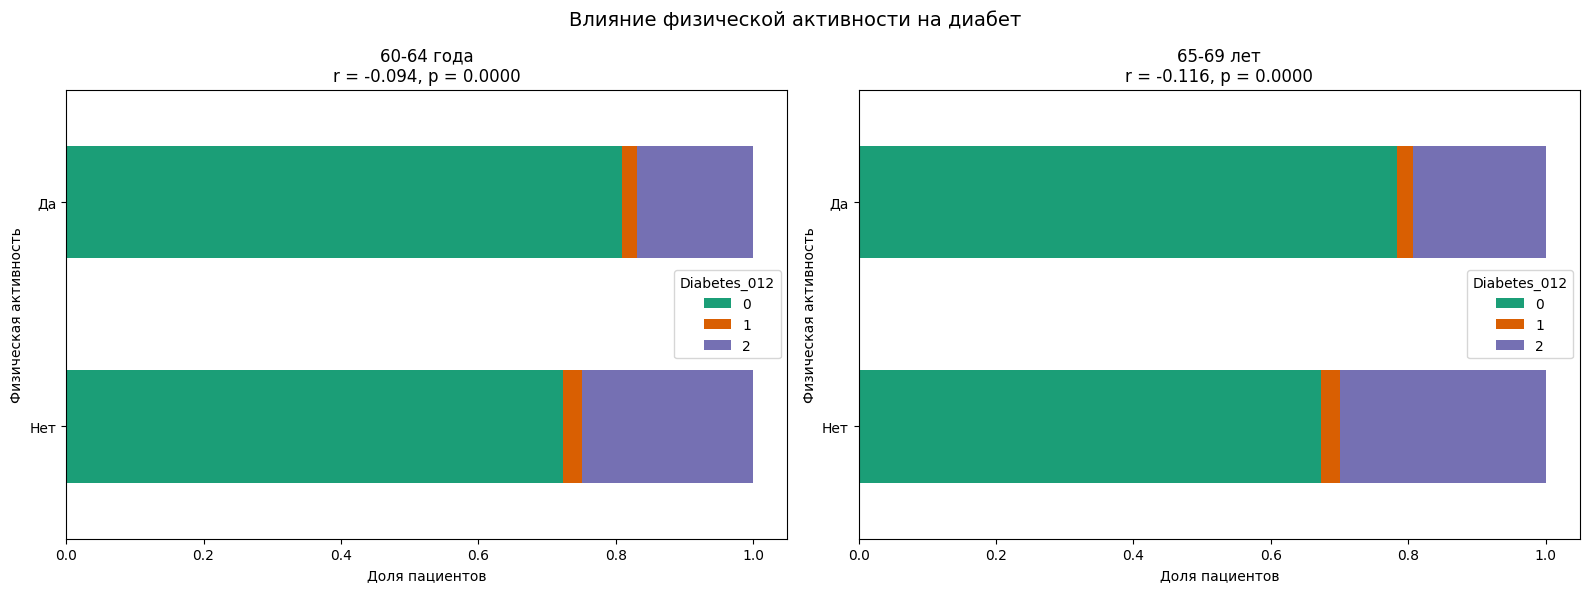

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    ct = pd.crosstab(grp['PhysActivity'], grp['Diabetes_012'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=['#1b9e77','#d95f02','#7570b3'])
    r, p = pointbiserialr(grp['PhysActivity'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    axes[i].set_yticklabels(['Нет', 'Да'])
    axes[i].set_xlabel('Доля пациентов')
    axes[i].set_ylabel('Физическая активность')

plt.suptitle('Влияние физической активности на диабет', fontsize=14)
plt.tight_layout()
plt.show()

**Заключение:** Наличие физической активности вне работы снижает риск диабета в обеих группах.

###  Fruits (бинарная) & Veggies (бинарная) vs Diabetes_012:

In [36]:
for feat, feat_name in [('Fruits', 'Потребление фруктов'), ('Veggies', 'Потребление овощей')]:
    print(f'--- {feat_name} ---')
    for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
        corr, p = pointbiserialr(grp[feat], grp['Diabetes_012'])
        print(f'  {name}: r = {corr:.3f}, p-value = {p:.4f}')
    print()

--- Потребление фруктов ---
  60-64 года: r = -0.040, p-value = 0.0000
  65-69 лет: r = -0.036, p-value = 0.0000

--- Потребление овощей ---
  60-64 года: r = -0.051, p-value = 0.0000
  65-69 лет: r = -0.058, p-value = 0.0000



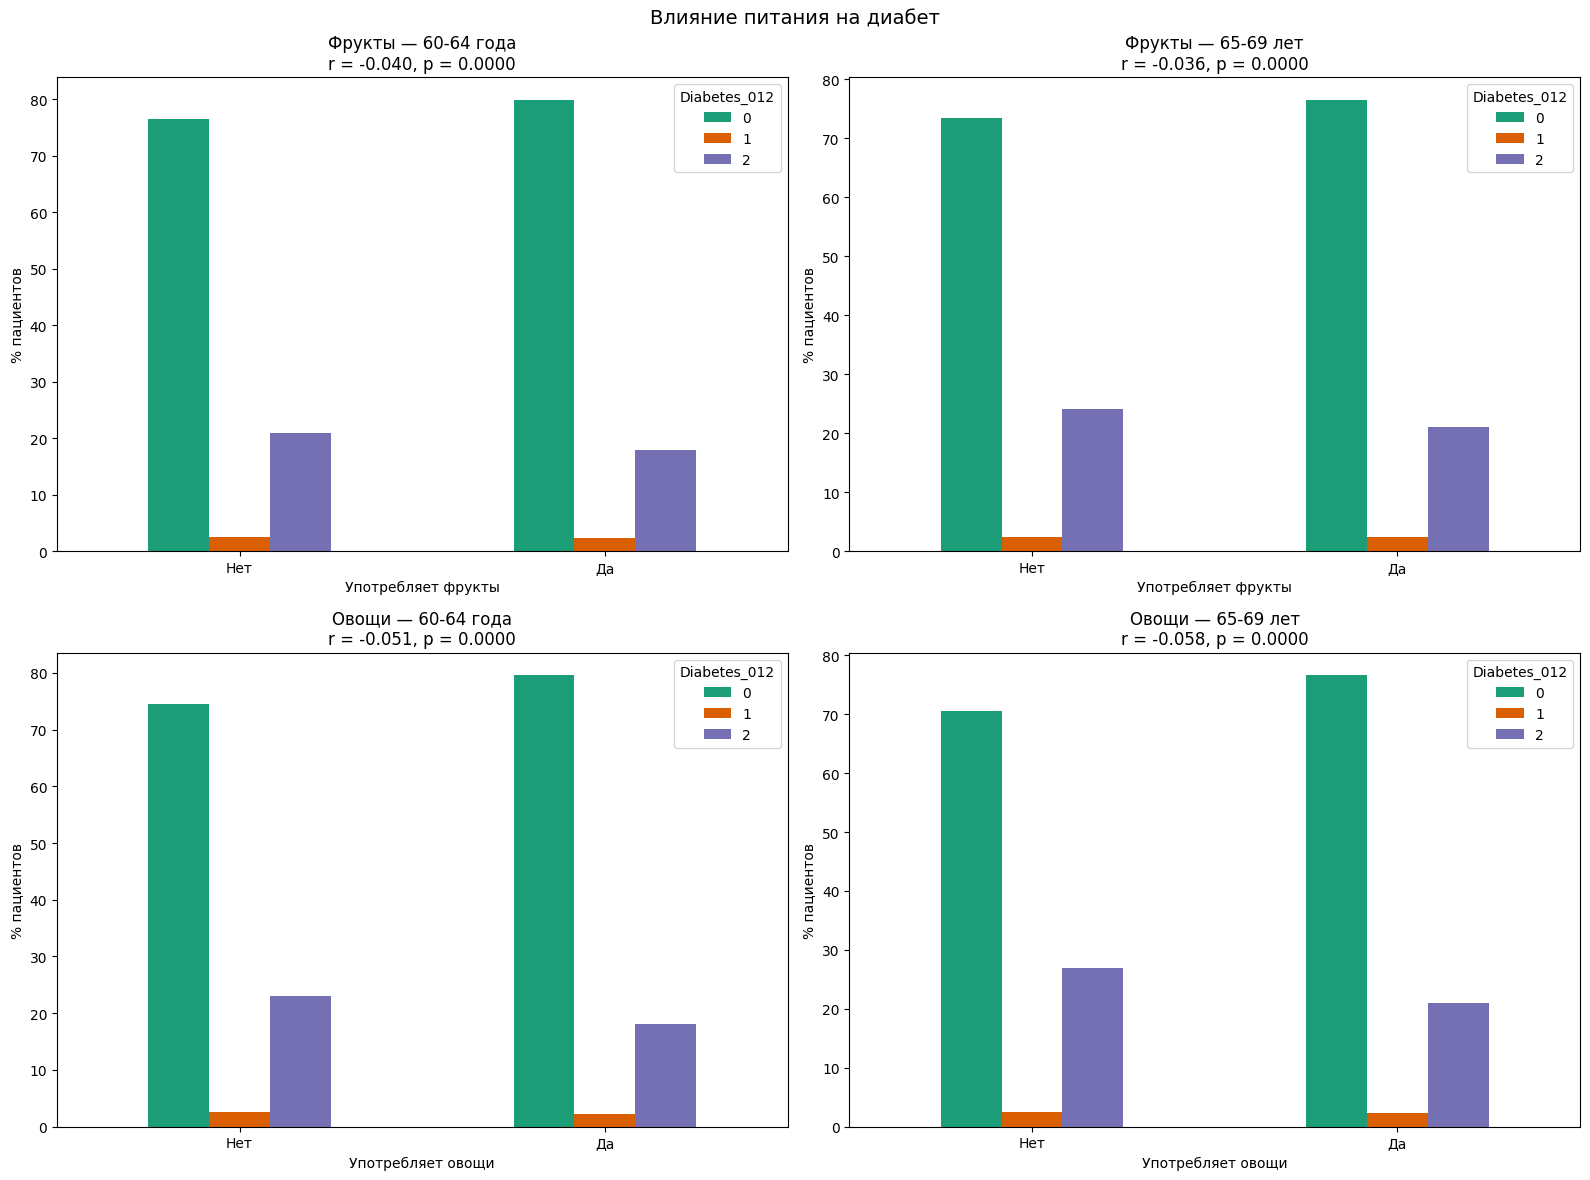

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (feat, feat_name) in enumerate([('Fruits', 'Фрукты'), ('Veggies', 'Овощи')]):
    for col, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
        ct = pd.crosstab(grp[feat], grp['Diabetes_012'], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[row, col], color=['#1b9e77','#d95f02','#7570b3'])
        r, p = pointbiserialr(grp[feat], grp['Diabetes_012'])
        axes[row, col].set_title(f'{feat_name} — {label}\nr = {r:.3f}, p = {p:.4f}')
        axes[row, col].set_xticklabels(['Нет', 'Да'], rotation=0)
        axes[row, col].set_xlabel(f'Употребляет {feat_name.lower()}')
        axes[row, col].set_ylabel('% пациентов')

plt.suptitle('Влияние питания на диабет', fontsize=14)
plt.tight_layout()
plt.show()

**Заключение:** Потребление фруктов и овощей слабо связано с наличием диабета (коэффициенты близки к нулю).

### DiffWalk (бинарная) vs Diabetes_012 — точечно-бисериальный коэффициент

In [38]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = pointbiserialr(grp['DiffWalk'], grp['Diabetes_012'])
    print(f'{name}: r = {corr:.3f}, p-value = {p:.4f}')

60-64 года: r = 0.205, p-value = 0.0000
65-69 лет: r = 0.202, p-value = 0.0000


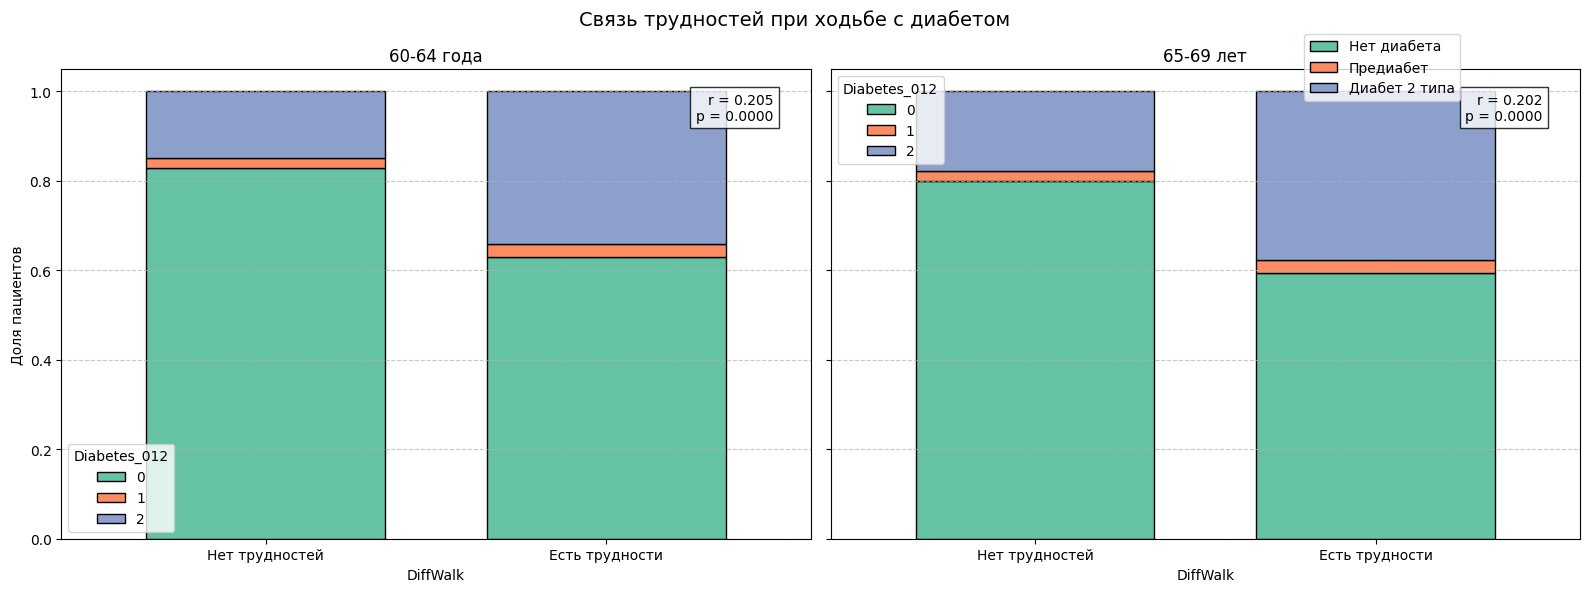

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    r, p = pointbiserialr(grp['DiffWalk'], grp['Diabetes_012'])
    ct = pd.crosstab(grp['DiffWalk'], grp['Diabetes_012'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, width=0.7, edgecolor='black')
    axes[i].text(0.95, 0.95, f'r = {r:.3f}\np = {p:.4f}',
                ha='right', va='top', transform=axes[i].transAxes,
                bbox=dict(facecolor='white', alpha=0.8))
    axes[i].set_title(label)
    axes[i].set_xticklabels(['Нет трудностей', 'Есть трудности'], rotation=0)
    axes[i].set_ylabel('Доля пациентов' if i == 0 else '')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Нет диабета', 'Предиабет', 'Диабет 2 типа'],
           loc='upper right', bbox_to_anchor=(0.92, 0.95))
plt.suptitle('Связь трудностей при ходьбе с диабетом', fontsize=14)
plt.tight_layout()
plt.show()

**Заключение:** Наличие трудностей при ходьбе значимо связано с наличием диабета у обеих групп.

### GenHlth (порядковая) vs Diabetes_012 — коэффициент Спирмена

In [40]:
for name, grp in [('60-64 года', group_9), ('65-69 лет', group_10)]:
    corr, p = spearmanr(grp['GenHlth'], grp['Diabetes_012'])
    print(f'{name}: ρ = {corr:.3f}, p-value = {p:.4f}')

60-64 года: ρ = 0.306, p-value = 0.0000
65-69 лет: ρ = 0.290, p-value = 0.0000


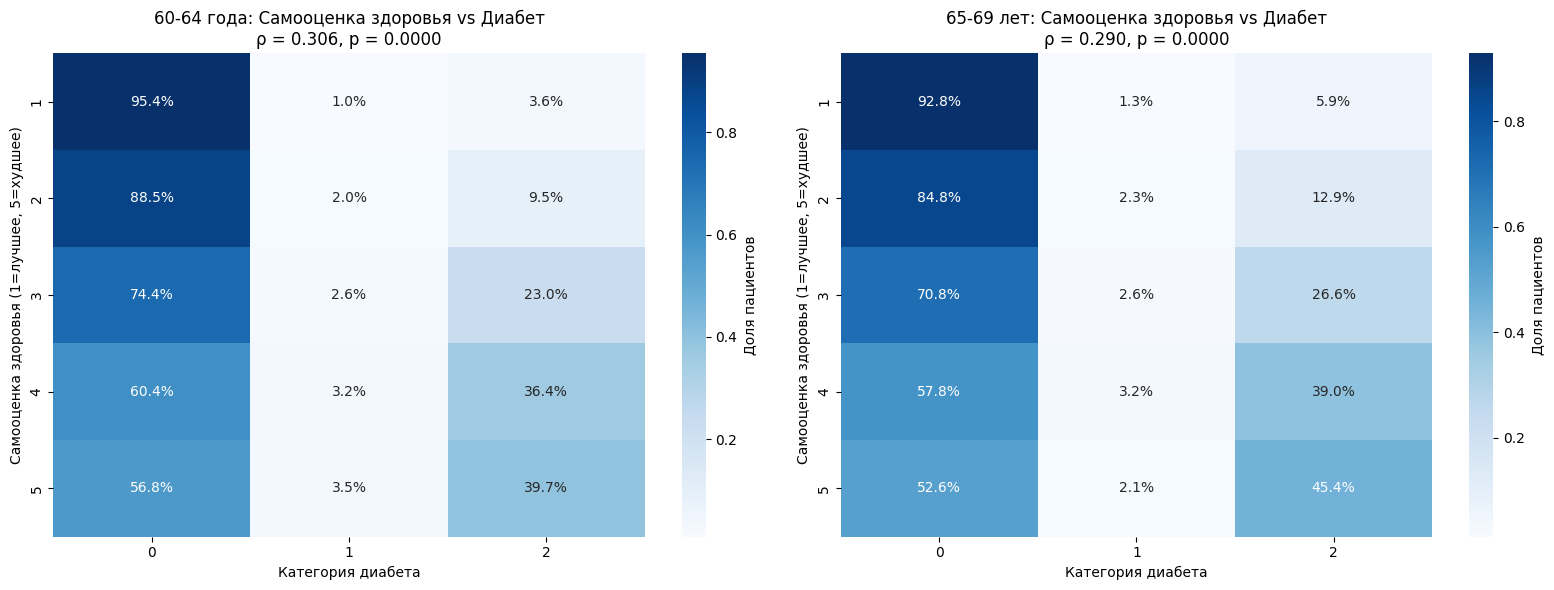

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, grp) in enumerate(zip(['60-64 года', '65-69 лет'], [group_9, group_10])):
    sns.heatmap(
        pd.crosstab(grp['GenHlth'], grp['Diabetes_012'], normalize='index'),
        annot=True, fmt='.1%', cmap='Blues',
        cbar_kws={'label': 'Доля пациентов'},
        ax=axes[i]
    )
    rho, p = spearmanr(grp['GenHlth'], grp['Diabetes_012'])
    axes[i].set_title(f'{label}: Самооценка здоровья vs Диабет\nρ = {rho:.3f}, p = {p:.4f}')
    axes[i].set_xlabel('Категория диабета')
    axes[i].set_ylabel('Самооценка здоровья (1=лучшее, 5=худшее)')

plt.tight_layout()
plt.show()

**Заключение:** Чем хуже самооценка здоровья (выше значение GenHlth), тем выше вероятность диабета. Коэффициент Спирмена показывает умеренную положительную связь.

## Экспорт обработанного датасета

In [42]:
data.duplicated().sum()

np.int64(0)

In [43]:
data_export = data.drop(columns=['age_group', 'bmi_category'])

output_path = '/home/alexey-rau/projects/omgtu/OMGTU/2year/4semester/MLDA/datasets/filtered_diabetes_health_indicators.csv'
data_export.to_csv(output_path, index=False)

print(f'Датасет сохранён: {output_path}')
print(f'Размер: {data_export.shape[0]} строк, {data_export.shape[1]} столбцов')
print(f'Столбцы: {list(data_export.columns)}')
data_export.head()

Датасет сохранён: /home/alexey-rau/projects/omgtu/OMGTU/2year/4semester/MLDA/datasets/filtered_diabetes_health_indicators.csv
Размер: 229718 строк, 22 столбцов
Столбцы: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4


In [44]:
data_export.duplicated().sum()

np.int64(0)

# Общие выводы:

Данный проект посвящён исследованию данных о здоровье пациентов с целью определения факторов, влияющих на возникновение диабета.

**Обработка данных:**
- Пропущенных значений не обнаружено.
- Все числовые данные преобразованы из float64 в int, поскольку содержат дискретные значения.
- Удалены дубликаты.
- Добавлены расшифровки возрастных групп (age_group) и категории по индексу массы тела (bmi_category).

**Анализ возраста:**
- Среднее значение кода возрастной группы: 8.1 (~55-59 лет), медиана: 8.
- Наибольшее число наблюдений приходится на группы 60-64 и 65-69 лет, которые были выбраны для детального анализа.

**Результаты корреляционного анализа (для возрастных групп 60-64 и 65-69 лет):**

| Признак | Тип | Метод | Связь с диабетом |
|---------|-----|-------|-----------------|
| BMI | Числовой | Спирмен | Положительная (умеренная) |
| GenHlth | Порядковый | Спирмен | Положительная (умеренная) |
| Income | Порядковый | Спирмен | Отрицательная (слабая) |
| HighBP | Бинарный | Точечно-бисериальный | Положительная |
| HighChol | Бинарный | Точечно-бисериальный | Положительная |
| DiffWalk | Бинарный | Точечно-бисериальный | Положительная |
| PhysActivity | Бинарный | Точечно-бисериальный | Отрицательная |
| Fruits | Бинарный | Точечно-бисериальный | Слабая |
| Veggies | Бинарный | Точечно-бисериальный | Слабая |

**Ключевые выводы:**
- Наиболее сильные факторы риска: высокое кровяное давление, высокий холестерин, высокий BMI, трудности при ходьбе, плохая самооценка здоровья.
- Защитные факторы: физическая активность, высокий доход.
- Связь потребления фруктов и овощей с диабетом статистически слабая.